# 3F - DHW e Kelvin: calor acumulado agrega leitura fisica?

**Pergunta especifica.** O DHW e apenas SSTA reembalada ou mantem informacao propria sobre SSTA futura quando controlamos SSTA atual, WWV e OHC? E ha sinal qualitativo de Kelvin downwelling na SSH equatorial?

**Objetivo.** Avaliar DHW como metrica de memoria/severidade e nao como rotulo de evento, comparando a convencao `12w > 1C` com a metrica ENSO-especifica `26w > P90 diario`.

**Justificativa.** O acumulado de 12 semanas veio da tradicao CRW e e util como referencia. Para Nino 3.4, a janela de 26 semanas e mais coerente com a memoria estimada da SSTA (~27 semanas) e o limiar P90 local evita importar uma convencao de coral para ENSO.

**Metodologia.** Calcula correlacao bruta e parcial de cada DHW com SSTA futura (+4, +8, +12 semanas), controlando SSTA/WWV/OHC. Para Kelvin, usa Hovmoller de SSH 1S-1N em janelas de eventos.

**Saidas.** `phase3F_dhw_redundancia.csv`, `phase3F_kelvin_resumo.csv`, `phase3F_dhw_serie.png`, `phase3F_hovmoller_ssh_kelvin.png`.


In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u
from nino_brasil.stats.significance import partial_correlation

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
w = weekly.loc['1993-01-01':]

DHW_METRICS = {
    'dhw_12w': '12w_gt_1C_CRW_herdado',
    'dhw_26w_p90': '26w_gt_P90_diario_ENSO',
}
rows = []
for metric, label in DHW_METRICS.items():
    for h in [4, 8, 12]:
        fut = w['nino34_ssta'].shift(-h)
        base = pd.DataFrame({'dhw': w[metric], 'fut': fut, 'ssta': w['nino34_ssta'],
                             'wwv': w['wwv'], 'ohc': w['ohc_0_300']}).dropna()
        r_bruto = float(np.corrcoef(base['dhw'], base['fut'])[0,1])
        pc = partial_correlation(base['dhw'].values, base['fut'].values,
                                 controls=base[['ssta','wwv','ohc']].values)
        rows.append({'metrica_dhw': metric, 'definicao': label, 'horizonte_semanas': h,
                     'r_bruto_dhw_ssta_fut': round(r_bruto,3),
                     'r_parcial_ctrl_ssta_wwv_ohc': round(pc['r'],3),
                     'n_eff_parcial': round(pc['n_eff'],1),
                     'p_efetivo_parcial': round(pc['p_effective'],4), 'n': int(pc['n'])})
red = pd.DataFrame(rows)
u.save_table(red, 'phase3F_dhw_redundancia.csv', index=False)
verdict = red.assign(sig=red['p_efetivo_parcial'] < 0.05).groupby('metrica_dhw')['sig'].any().to_dict()
print('veredito 3F por metrica:', verdict)
red


[tabela] data\processed\parquet\statistics\phase3F_dhw_redundancia.csv
veredito 3F por metrica: {'dhw_12w': True, 'dhw_26w_p90': False}


,metrica_dhw,definicao,horizonte_semanas,r_bruto_dhw_ssta_fut,r_parcial_ctrl_ssta_wwv_ohc,n_eff_parcial,p_efetivo_parcial,n
0,dhw_12w,12w_gt_1C_CRW_herdado,4,0.541,0.478,25.4,0.0148,1742
1,dhw_12w,12w_gt_1C_CRW_herdado,8,0.443,0.402,23.7,0.0530,1738
2,dhw_12w,12w_gt_1C_CRW_herdado,12,0.327,0.311,22.9,0.1496,1734
3,dhw_26w_p90,26w_gt_P90_diario_ENSO,4,0.376,0.274,25.0,0.1845,1742
4,dhw_26w_p90,26w_gt_P90_diario_ENSO,8,0.261,0.192,23.4,0.3756,1738
5,dhw_26w_p90,26w_gt_P90_diario_ENSO,12,0.145,0.112,22.6,0.6159,1734


[figura] data\processed\figures\fase3\phase3F_dhw_serie.png


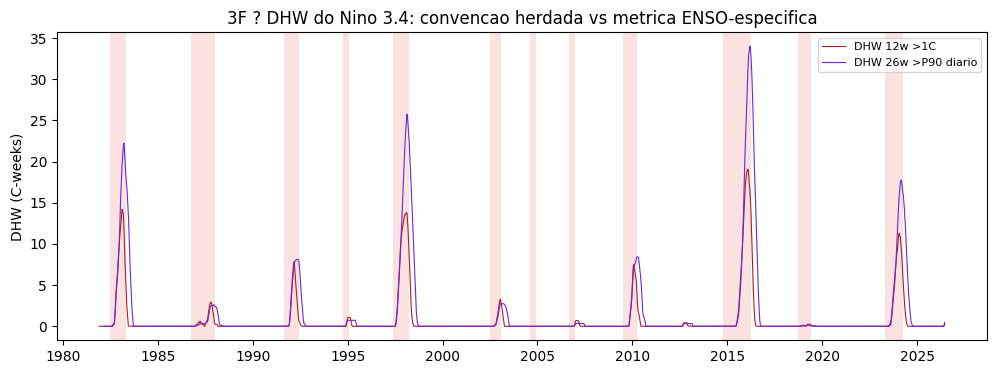

In [2]:
# Figura 3F-1: DHW com eventos sombreados
# Compara a convencao herdada de 12 semanas com a janela ENSO-especifica de 26 semanas/P90.
ev = u.load_events()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly.index, weekly['dhw_12w'], lw=0.8, color='#b71c1c', label='DHW 12w >1C')
ax.plot(weekly.index, weekly['dhw_26w_p90'], lw=0.8, color='#6d28d9', label='DHW 26w >P90 diario')
u.add_event_shading(ax, ev)
ax.set_ylabel('DHW (C-weeks)'); ax.set_title('3F - DHW do Nino 3.4: convencao herdada vs metrica ENSO-especifica')
ax.legend(fontsize=8)
u.save_fig(fig, 'phase3F_dhw_serie.png')
plt.show()


[figura] data\processed\figures\fase3\phase3F_hovmoller_ssh_kelvin.png
[tabela] data\processed\parquet\statistics\phase3F_kelvin_resumo.csv


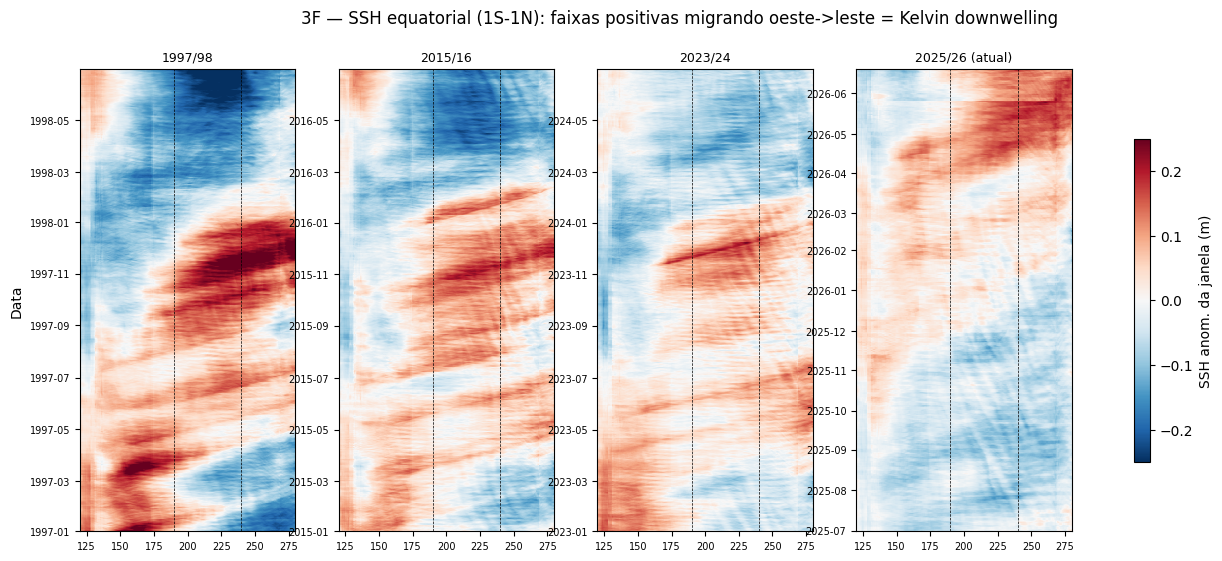

,janela,ssh_max_m
0,1997/98,0.326
1,2015/16,0.233
2,2023/24,0.241
3,2025/26 (atual),0.237


In [3]:
# Mapa 3F-1: Hovmoller SSH equatorial (Kelvin) nos anos de evento
ssh = u.load_ssh_events()
windows = [('1997-01-01','1998-06-30','1997/98'), ('2015-01-01','2016-06-30','2015/16'),
           ('2023-01-01','2024-06-30','2023/24'), ('2025-07-01','2026-06-19','2025/26 (atual)')]
fig, axes = plt.subplots(1, len(windows), figsize=(16, 6), sharex=True)
lon = ssh.columns.values
for ax, (t0, t1, ttl) in zip(axes, windows):
    seg = ssh.loc[t0:t1]
    anom = seg - seg.mean()
    pc = ax.pcolormesh(lon, anom.index, anom.values, cmap='RdBu_r', vmin=-0.25, vmax=0.25, shading='auto')
    ax.axvline(190, color='k', ls='--', lw=0.5); ax.axvline(240, color='k', ls='--', lw=0.5)
    ax.set_title(ttl, fontsize=9); ax.tick_params(labelsize=7)
axes[0].set_ylabel('Data')
fig.suptitle('3F — SSH equatorial (1S-1N): faixas positivas migrando oeste->leste = Kelvin downwelling')
fig.colorbar(pc, ax=axes, label='SSH anom. da janela (m)', shrink=0.7)
u.save_fig(fig, 'phase3F_hovmoller_ssh_kelvin.png')
vel = pd.DataFrame([{'janela': ttl, 'ssh_max_m': round(float((ssh.loc[t0:t1]-ssh.loc[t0:t1].mean()).max().max()),3)} for t0,t1,ttl in windows])
u.save_table(vel, 'phase3F_kelvin_resumo.csv', index=False)
plt.show()
vel

**Leitura do 3F.** A correlação parcial responde diretamente à regra do protocolo: se, controlando SSTA/WWV/OHC, o DHW mantém parcial significativa com a SSTA futura, ele carrega memória térmica integrada própria (duração × intensidade do estresse) e entra no parecer; caso contrário fica como diagnóstico descritivo. Os Hovmöller de SSH mostram os pulsos de Kelvin downwelling atravessando a bacia nos eventos históricos e na janela atual 2025/26 — a leitura direcional (oeste→leste) é qualitativa e auditável, sem modelo.